# AstroPrism Tutorial: Multi-Instrument Pipeline

This tutorial extends the single-instrument pipeline to jointly fit data from multiple instruments (JWST MIRI + JWST NIRCam) under a shared sky model using Gaussian Processes.

**What you'll learn:**
1. Loading and organizing data from multiple instruments into a `MultiInstrumentDataset`
2. Building a shared GP sky model across all channels
3. Modeling per-channel instrument responses (reprojection + PSF convolution)
4. Jointly fitting all instruments with a single likelihood
5. Analyzing the posterior across instruments

## Environment

To run this tutorial, create a virtual environment and install AstroPrism in editable mode:

```bash
cd /path/to/astroprism

# Create and activate a virtual environment
python3 -m venv .venv
source .venv/bin/activate

# Install AstroPrism with dev dependencies
pip install -e ".[dev]"

# Register the Jupyter kernel
python -m ipykernel install --user --name=astroprism
```

Then select the **astroprism** kernel in Jupyter or VS Code.

## Imports

In [3]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import warnings
from astropy.utils.exceptions import AstropyWarning

import jax
import jax.numpy as jnp
import jax.random as jr
import nifty8.re as jft

warnings.filterwarnings('ignore', category=AstropyWarning)

### 1. Data Loading

`load_multiple_datasets` takes a dict mapping instrument keys to data paths and returns a `MultiInstrumentDataset`. Channel keys are prefixed as `instrument:channel` (e.g. `JWST_MIRI:f770w`).

MultiInstrumentDataset Summary:
--------------------------------
Number of instruments: 2
Instrument keys: ['JWST_MIRI', 'JWST_NIRCAM']
Number of channels: 8
Channel keys: ['JWST_MIRI:jwst_miri_ngc1566_f1000w', 'JWST_MIRI:jwst_miri_ngc1566_f1130w', 'JWST_MIRI:jwst_miri_ngc1566_f2100w', 'JWST_MIRI:jwst_miri_ngc1566_f770w', 'JWST_NIRCAM:jwst_nircam_ngc1566_f200w', 'JWST_NIRCAM:jwst_nircam_ngc1566_f300m', 'JWST_NIRCAM:jwst_nircam_ngc1566_f335m', 'JWST_NIRCAM:jwst_nircam_ngc1566_f360m']
Channel shapes: [(2125, 1814), (2125, 1814), (2125, 1814), (2125, 1814), (8764, 5273), (4244, 2530), (4244, 2530), (4244, 2530)]
Pixel scales: [(0.11091449975820492, 0.1109144997630491), (0.11091449949791077, 0.11091449946799463), (0.11091449907273217, 0.11091449905375952), (0.11091450012231652, 0.11091450010349585), (0.030745888186397542, 0.030745888214638056), (0.06299856561171978, 0.06299856559416088), (0.06299972112784198, 0.06299972115150834), (0.06299972200415113, 0.06299972199117361)]



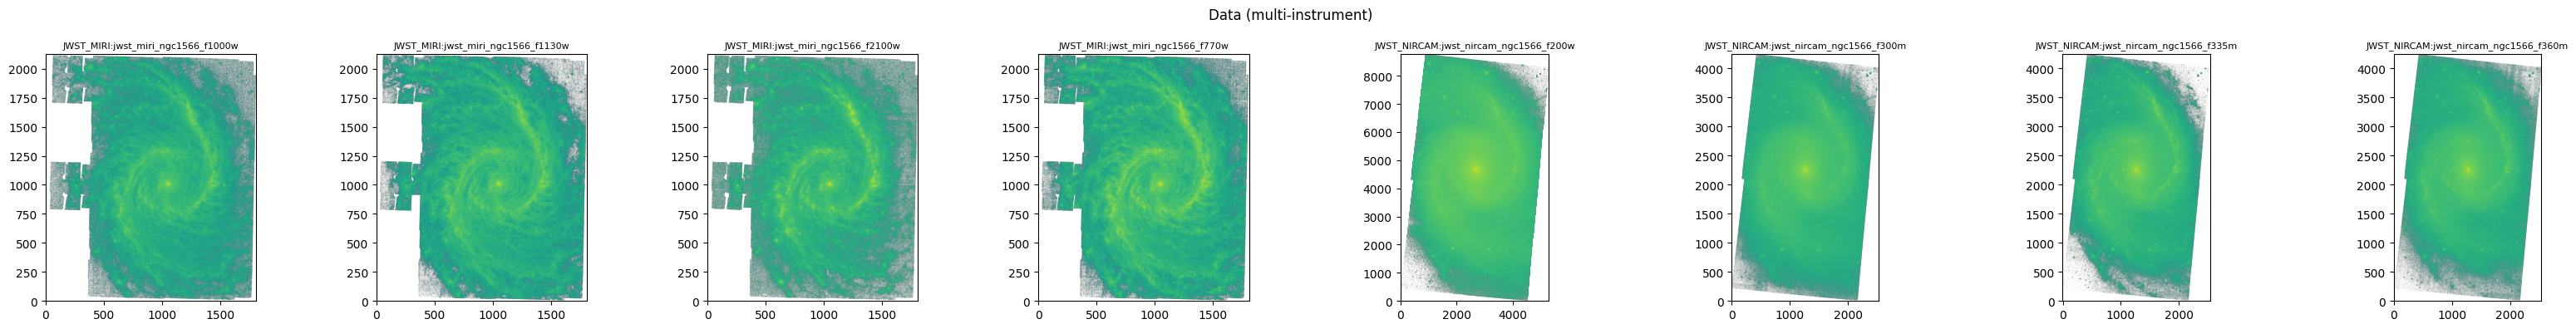

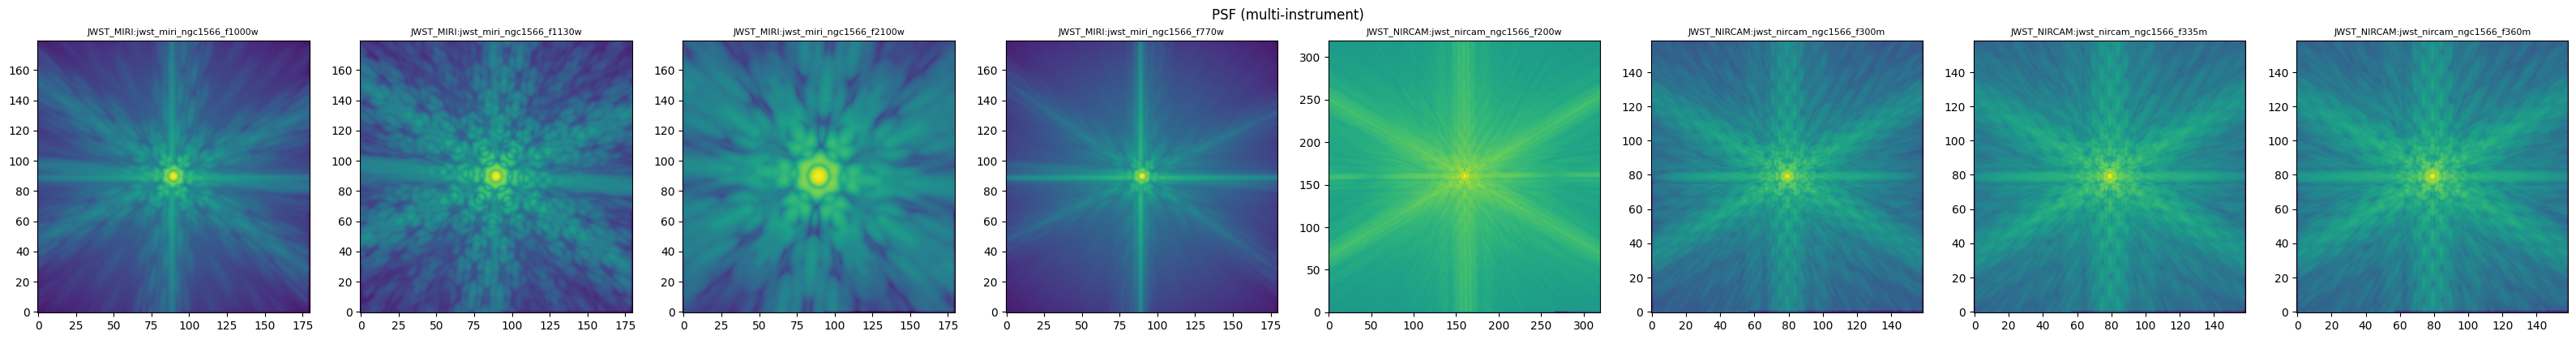

In [5]:
# Imports
from astroprism.io import load_multiple_datasets, MultiInstrumentDataset

# Load Multi-Instrument Dataset
paths = {
    "JWST_MIRI":   "../data/tutorial/jwst_miri/", # _cutout works too
    "JWST_NIRCAM": "../data/tutorial/jwst_nircam/",
}
dataset = load_multiple_datasets(paths_dict=paths, extension="fits")
print(dataset.summary())

# Plot Data — one panel per channel, labelled by instrument:channel
n = dataset.n_channels
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for i, key in enumerate(dataset.channel_keys):
    data, wcs, psf = dataset[key]
    axes[i].imshow(data, norm=LogNorm(), origin='lower')
    axes[i].set_title(key, fontsize=8)
plt.suptitle("Data (multi-instrument)")
plt.tight_layout()
plt.show()

# Plot PSFs
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for i, key in enumerate(dataset.channel_keys):
    _, _, psf = dataset[key]
    axes[i].imshow(psf, norm=LogNorm(), origin='lower')
    axes[i].set_title(key, fontsize=8)
plt.suptitle("PSF (multi-instrument)")
plt.tight_layout()
plt.show()

In [6]:
from astroprism.io import SingleInstrumentDataset

# Keep only the first 2 channels per instrument for quick testing
n_keep = 2
trimmed = {}
for key, ds in dataset.instrument_datasets.items():
    trimmed[key] = SingleInstrumentDataset(
        data=ds.data[:n_keep],
        wcs=ds.wcs[:n_keep],
        psfs=ds.psfs[:n_keep],
        channel_keys=ds.channel_keys[:n_keep],
    )
dataset = MultiInstrumentDataset(instrument_datasets=trimmed)
print(dataset.summary())

MultiInstrumentDataset Summary:
--------------------------------
Number of instruments: 2
Instrument keys: ['JWST_MIRI', 'JWST_NIRCAM']
Number of channels: 4
Channel keys: ['JWST_MIRI:jwst_miri_ngc1566_f1000w', 'JWST_MIRI:jwst_miri_ngc1566_f1130w', 'JWST_NIRCAM:jwst_nircam_ngc1566_f200w', 'JWST_NIRCAM:jwst_nircam_ngc1566_f300m']
Channel shapes: [(2125, 1814), (2125, 1814), (8764, 5273), (4244, 2530)]
Pixel scales: [(0.11091449975820492, 0.1109144997630491), (0.11091449949791077, 0.11091449946799463), (0.030745888186397542, 0.030745888214638056), (0.06299856561171978, 0.06299856559416088)]



In [ ]:
import copy
import numpy as np
from astropy.wcs.utils import pixel_to_pixel

# Crop all channels to the same sky position (MIRI image center), at each
# instrument's native pixel resolution.
#
# NOTE: NIRCam's pixel scale is ~3.5x finer than MIRI, so the same sky area
# contains ~12x more pixels. For quick CPU testing use crop_size ~ 256-512.
# For full-resolution multi-instrument fitting, a GPU is recommended.

crop_size = 512   # pixels per side — adjust for speed vs coverage trade-off

miri_ref = dataset.get_instrument_dataset("JWST_MIRI")
ref_wcs   = miri_ref.wcs[0]
ref_ny, ref_nx = miri_ref.shapes[0]
ref_cx, ref_cy = (ref_nx - 1) / 2.0, (ref_ny - 1) / 2.0

def crop_channel(data, wcs, crop_size, ref_wcs, ref_cx, ref_cy):
    """Center-crop around the sky position (ref_cx, ref_cy) in ref_wcs."""
    ny, nx = data.shape
    px, py = pixel_to_pixel(ref_wcs, wcs, ref_cx, ref_cy)
    cx, cy = int(round(float(px))), int(round(float(py)))
    half = crop_size // 2
    x0 = min(max(cx - half, 0), max(nx - crop_size, 0))
    y0 = min(max(cy - half, 0), max(ny - crop_size, 0))
    data_crop = data[y0:y0+crop_size, x0:x0+crop_size]
    wcs_crop = copy.deepcopy(wcs)
    wcs_crop.wcs.crpix[0] -= x0
    wcs_crop.wcs.crpix[1] -= y0
    wcs_crop.array_shape = data_crop.shape
    return data_crop, wcs_crop

cropped = {}
for key, ds in dataset.instrument_datasets.items():
    data_list, wcs_list = [], []
    for d, w in zip(ds.data, ds.wcs):
        dc, wc = crop_channel(d, w, crop_size, ref_wcs, ref_cx, ref_cy)
        data_list.append(dc)
        wcs_list.append(wc)
    cropped[key] = SingleInstrumentDataset(
        data=data_list,
        wcs=wcs_list,
        psfs=ds.psfs,
        channel_keys=ds.channel_keys,
    )
dataset = MultiInstrumentDataset(instrument_datasets=cropped)
print(dataset.summary())

# Plot cropped data — pixel coordinates
n = dataset.n_channels
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for i, key in enumerate(dataset.channel_keys):
    data, _, _ = dataset[key]
    axes[i].imshow(data, norm=LogNorm(), origin='lower')
    axes[i].set_title(f"{key}\n{data.shape}", fontsize=8)
plt.suptitle("Cropped Data (pixel)")
plt.tight_layout()
plt.show()

# Plot cropped data — sky projection (RA/Dec)
fig = plt.figure(figsize=(4*n, 4))
for i, key in enumerate(dataset.channel_keys):
    data, wcs, _ = dataset[key]
    ax = fig.add_subplot(1, n, i+1, projection=wcs)
    ax.imshow(data, norm=LogNorm(), origin='lower')
    ax.coords[0].set_axislabel("RA")
    ax.coords[1].set_axislabel("Dec")
    ax.coords[1].set_ticklabel_visible(i == 0)
    ax.set_title(key, fontsize=8)
plt.suptitle("Cropped Data (sky)")
plt.tight_layout()
plt.show()

### 2. Set Up GP Prior

The sky model is defined on a single reference frame shared across all instruments. We choose the first MIRI channel as the reference (coarsest resolution). NIRCam channels are reprojected onto this frame in step 3.

`SpatialGP` is built on the reference shape/pixel-scale; `MixtureGP` mixes across all `n_channels`.

In [8]:
# Imports
from astroprism.models.gp import SpatialGP, MixtureGP

# Use the first MIRI channel as the reference sky frame
miri_ds = dataset.get_instrument_dataset("JWST_MIRI")
signal_wcs   = miri_ds.wcs[0]
signal_shape = miri_ds.shapes[0]

# SpatialGP: correlated field on the sky reference frame
spatial_gp = SpatialGP(
    n_channels=dataset.n_channels,
    shape=signal_shape,
    distances=miri_ds.pixel_scales[0],
)

# MixtureGP: linear mixing across all channels (MIRI + NIRCam)
mixture = MixtureGP(spatial_gps=spatial_gp)

print("MixtureGP domain keys:", list(mixture.domain.keys()))
print(f"Sky model shape: {signal_shape}, n_channels: {dataset.n_channels}")

MixtureGP domain keys: ['zeromode', 'fluctuations', 'loglogavgslope', 'spectrum', 'flexibility', 'xi', 'mixture_matrix', 'mixing_offset']
Sky model shape: (2125, 1814), n_channels: 4


### 3. Set Up the Instrument Response Model

`InstrumentResponse` accepts the full `MultiInstrumentDataset` directly — it builds one reprojector and one convolver per channel, regardless of which instrument the channel belongs to.

In [9]:
# Imports
from astroprism.models.response import InstrumentResponse

# Instrument Response: one reprojector + convolver per channel
response = InstrumentResponse(
    dataset=dataset,
    signal_wcs=signal_wcs,
    signal_shape=signal_shape,
)

print("InstrumentResponse domain keys:", list(response.domain.keys()))

InstrumentResponse domain keys: ['psf_sigma', 'psf_rotation']


### 4. Set Up the Noise Model

In [10]:
# Imports
from astroprism.models.noise import NoiseModel

# NoiseModel: one noise level per channel
noise = NoiseModel(n_channels=dataset.n_channels)

print("NoiseModel domain keys:", list(noise.domain.keys()))

NoiseModel domain keys: ['background_std', 'poisson_scale']


### 5. Set Up the Forward Model

In [12]:
# Imports
from astroprism.models.forward import ForwardModel

# ForwardModel: sky → reprojection → PSF convolution → noise
model = ForwardModel(mixture, response, noise)

print("ForwardModel domain keys:", list(model.domain.keys()))

ForwardModel domain keys: ['zeromode', 'fluctuations', 'loglogavgslope', 'spectrum', 'flexibility', 'xi', 'mixture_matrix', 'mixing_offset', 'psf_sigma', 'psf_rotation', 'background_std', 'poisson_scale']


### 6. Set Up the Likelihood and Run Inference

The likelihood is built over all channels from both instruments simultaneously — the joint fit.

In [ ]:
# Imports
from astroprism.models.likelihood import build_likelihood
from astroprism.inference.vi import run_inference

# Joint likelihood across all MIRI + NIRCam channels
likelihood = build_likelihood(dataset, model, mask=dataset.readout)

# Run inference
samples, state = run_inference(
    likelihood,
    n_iterations=10,
    n_samples=2,
    seed=42,
    output_directory="tutorial_results_multi"
)

/opt/homebrew/Cellar/python@3.14/3.14.0_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/genericpath.py:39: RuntimeWarning: bool is used as a file descriptor
  st = os.stat(path)
OPTIMIZE_KL: Starting 0001


Starting VI optimization: 10 iterations, 2 samples.


E0328 15:55:18.214553 3254326 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %convert_element_type.587 = s32[31610408]{0} convert(%constant.1743), metadata={op_name="jit(draw_linear_residual)/while/body/cond/branch_1_fun/jit(<unknown>)/jvp()/convert_element_type" stack_frame_id=683}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0328 15:55:18.320873 3254224 slow_operation_alarm.cc:140] The operation took 1.118365s
Constant folding an instruction is taking > 1s:

  %convert_element_type.587 = s32[31610408]{0} convert(%constant.1743), metadata={op_name="jit(draw_linear_residual)/while/body/cond/branch_1_fun/

### 7. Analyze the Posterior

Channels are in the order returned by `dataset.channel_keys` (all MIRI channels first, then NIRCam).

In [ ]:
import pickle

# Load results
results_dir = Path("tutorial_results_multi")
samples, state = pickle.load(open(results_dir / "last.pkl", "rb"))

# Posterior mean
posterior_means = jft.mean(samples)

# Predicted sky signal (on reference frame)
pred_signal_mean = mixture(posterior_means)

# Predicted data per channel
pred_data_mean = response(posterior_means, pred_signal_mean)

# Plot Predicted Sky Signal
n = dataset.n_channels
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for i, key in enumerate(dataset.channel_keys):
    axes[i].imshow(pred_signal_mean[i], origin='lower', norm=LogNorm())
    axes[i].set_title(key, fontsize=8)
plt.suptitle("Predicted Sky Signal (reference frame)")
plt.tight_layout()
plt.show()

# Plot Predicted Data (reprojected + convolved)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for i, key in enumerate(dataset.channel_keys):
    axes[i].imshow(pred_data_mean[i], origin='lower', norm=LogNorm())
    axes[i].set_title(key, fontsize=8)
plt.suptitle("Predicted Data")
plt.tight_layout()
plt.show()

# Plot Observed Data
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for i, key in enumerate(dataset.channel_keys):
    data, _, _ = dataset[key]
    axes[i].imshow(data, norm=LogNorm(), origin='lower')
    axes[i].set_title(key, fontsize=8)
plt.suptitle("Observed Data")
plt.tight_layout()
plt.show()

# Plot Residuals (data - predicted, per channel)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for i, key in enumerate(dataset.channel_keys):
    data, _, _ = dataset[key]
    residual = data - pred_data_mean[i]
    axes[i].imshow(residual, origin='lower', cmap='RdBu_r')
    axes[i].set_title(key, fontsize=8)
plt.suptitle("Residuals (data - predicted)")
plt.tight_layout()
plt.show()

## Summary

In this tutorial, you ran a joint multi-instrument fit with AstroPrism:

| Step | Component | Purpose |
|------|-----------|---------|
| 1 | `MultiInstrumentDataset` | Load MIRI + NIRCam into a single dataset |
| 2 | `MixtureGP` | Shared GP sky model on the MIRI reference frame |
| 3 | `InstrumentResponse` | Per-channel reprojection + PSF convolution |
| 4 | `NoiseModel` | Per-channel heteroscedastic noise |
| 5 | `ForwardModel` | Combine all components |
| 6 | Joint Likelihood & Inference | Fit all instruments simultaneously |
| 7 | Analysis | Posterior sky signal and per-instrument residuals |